In [2]:
import pandas as pd
import shap
import lightgbm as lgb
import re

# 1. Chargement et nettoyage des colonnes pour LightGBM
print(" Chargement des données...")
df = pd.read_csv('data/train_cleaned_final.csv').fillna(0)
df.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in df.columns]

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# 2. Ton modèle champion issu de l'Étape 4 (Trial 5)
best_params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
    'learning_rate': 0.0463,
    'num_leaves': 84,
    'feature_fraction': 0.677,
    'bagging_fraction': 0.661,
    'min_child_samples': 12,
    'n_estimators': 150,
    'n_jobs': -1,
    'verbosity': -1
}

model = lgb.LGBMClassifier(**best_params)
model.fit(X, y)

# 3. Initialisation de SHAP (on prend 500 clients pour que ce soit rapide)
print(" Calcul des valeurs SHAP...")
explainer = shap.TreeExplainer(model)
X_sample = X.iloc[:500]
shap_values = explainer(X_sample)

# Initialiser l'affichage JavaScript dans le notebook (requis pour SHAP)
shap.initjs()

ModuleNotFoundError: No module named 'shap'

📊 IMPORTANCE GLOBALE (Vision Banque)


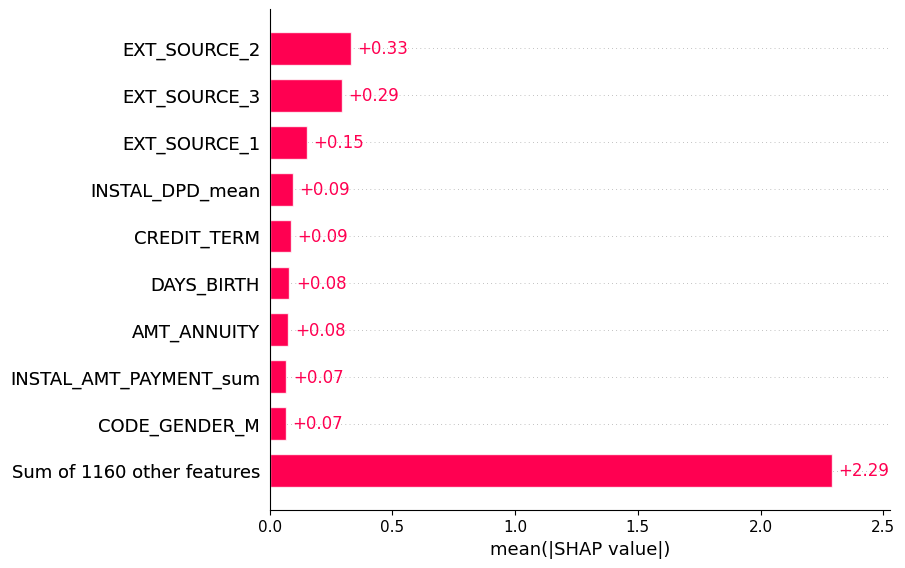



✅ IMPORTANCE LOCALE : Client ACCEPTÉ (Index 1 - Probabilité de risque : 0.13)


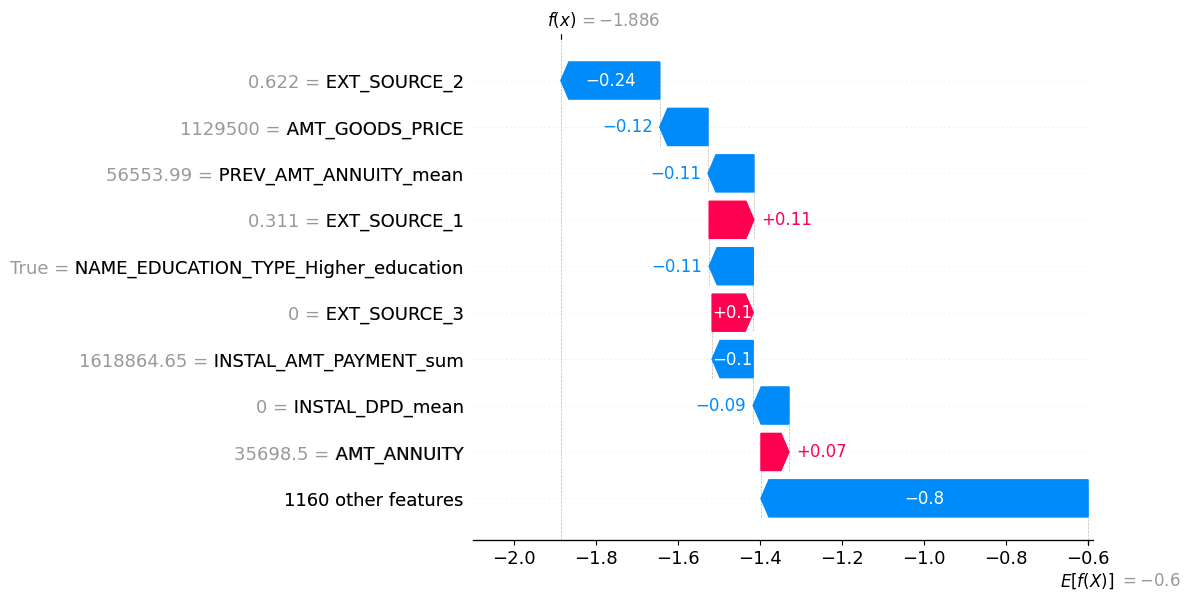



❌ IMPORTANCE LOCALE : Client REFUSÉ (Index 0 - Probabilité de risque : 0.78)


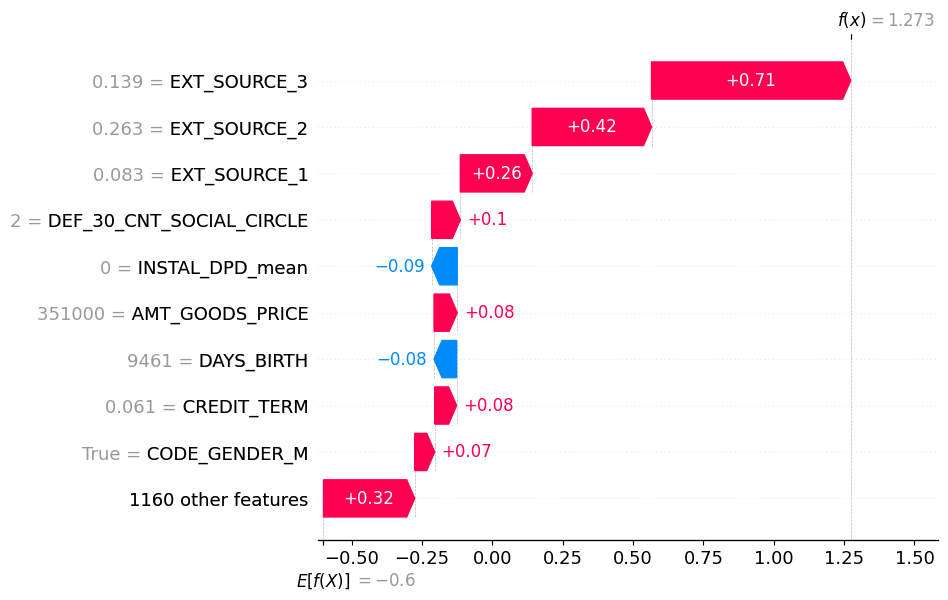

In [ ]:
# --- 1. IMPORTANCE GLOBALE ---
print(" IMPORTANCE GLOBALE (Vision Banque)")
shap.plots.bar(shap_values, max_display=10)

# --- 2. SÉLECTION DES CLIENTS ---
probs = model.predict_proba(X_sample)[:, 1]
seuil = 0.51  # Ton seuil optimal trouvé à l'étape 4

# Trouver les index du premier accepté et du premier refusé
idx_accepte = [i for i, p in enumerate(probs) if p < seuil][0]
idx_refuse = [i for i, p in enumerate(probs) if p > seuil][0]

print("\n" + "="*50 + "\n")

# --- 3. IMPORTANCE LOCALE : CLIENT ACCEPTÉ ---
print(f"✅ IMPORTANCE LOCALE : Client ACCEPTÉ (Index {idx_accepte} - Probabilité de risque : {probs[idx_accepte]:.2f})")
shap.plots.waterfall(shap_values[idx_accepte], max_display=10)

print("\n" + "="*50 + "\n")

# --- 4. IMPORTANCE LOCALE : CLIENT REFUSÉ ---
print(f"❌ IMPORTANCE LOCALE : Client REFUSÉ (Index {idx_refuse} - Probabilité de risque : {probs[idx_refuse]:.2f})")
shap.plots.waterfall(shap_values[idx_refuse], max_display=10)